In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


Data Collection and Processing

In [2]:

heart_data = pd.read_csv('heart_disease_data.csv')

In [3]:

heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:

heart_data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [5]:

heart_data.shape

(303, 14)

In [6]:

heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:

heart_data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
# statistical measures about the data
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
# checking the distribution of Target Variable
heart_data['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

1 --> Defective Heart

0 --> Healthy Heart

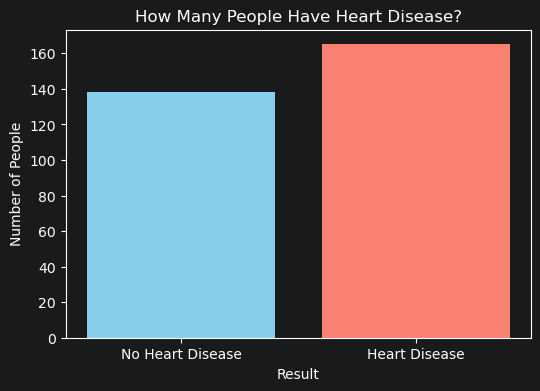

In [10]:
# Simple count chart for the target column
plt.figure(figsize=(6, 4))
labels = ['No Heart Disease', 'Heart Disease']
counts = heart_data['target'].value_counts().sort_index()
colors = ['skyblue', 'salmon']

plt.bar(labels, counts, color=colors)
plt.title('How Many People Have Heart Disease?')
plt.xlabel('Result')
plt.ylabel('Number of People')

plt.show()


This heatmap shows how strongly columns are related to each other. Dark red means a strong positive relation, and dark blue means a strong negative relation.

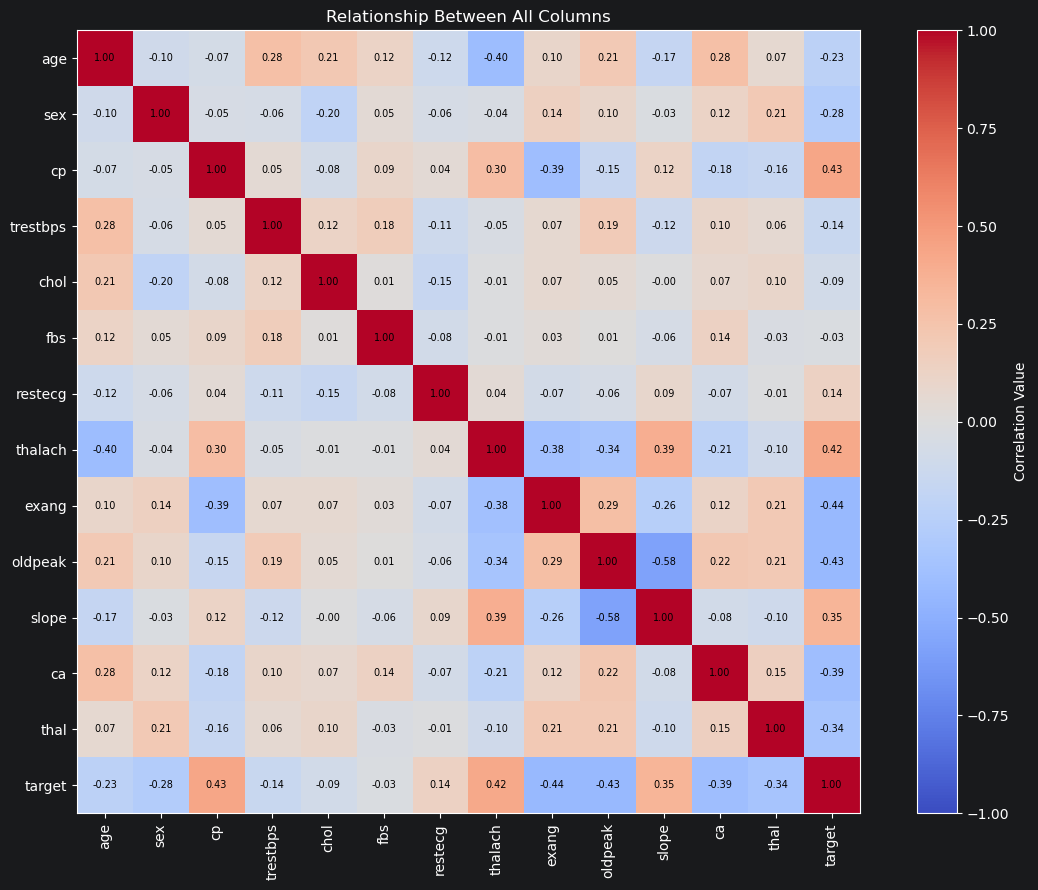

In [11]:
# Beginner-friendly correlation heatmap with values
correlation = heart_data.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
plt.imshow(correlation, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Value')
plt.title('Relationship Between All Columns')
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

# Show the correlation value inside each box
for row in range(len(correlation.columns)):
    for col in range(len(correlation.columns)):
        value = correlation.iloc[row, col]
        plt.text(col, row, f'{value:.2f}', ha='center', va='center', fontsize=7, color='black')

plt.tight_layout()
plt.show()


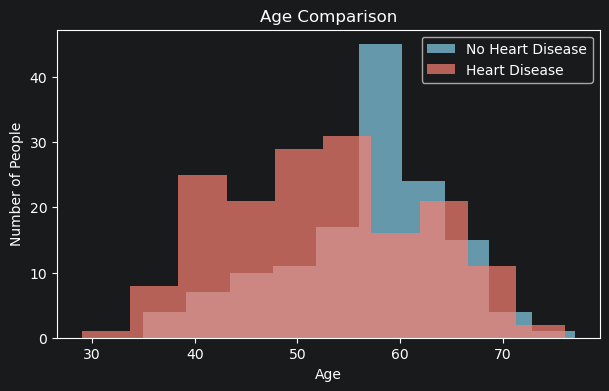

In [12]:
# Age comparison chart
plt.figure(figsize=(7, 4))

plt.hist(heart_data[heart_data['target'] == 0]['age'], bins=10, alpha=0.7, label='No Heart Disease', color='skyblue')
plt.hist(heart_data[heart_data['target'] == 1]['age'], bins=10, alpha=0.7, label='Heart Disease', color='salmon')

plt.title('Age Comparison')
plt.xlabel('Age')
plt.ylabel('Number of People')
plt.legend()
plt.show()


This chart shows which chest pain types appear more often for people with and without heart disease.

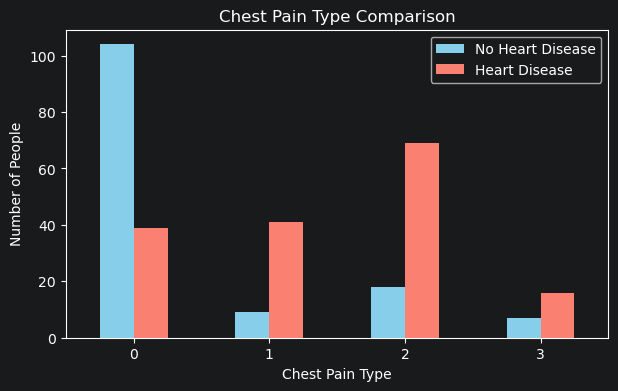

In [46]:
# Chest pain type comparison
chest_pain_chart = pd.crosstab(heart_data['cp'], heart_data['target'])
chest_pain_chart.columns = ['No Heart Disease', 'Heart Disease']

chest_pain_chart.plot(kind='bar', figsize=(7, 4), color=['skyblue', 'salmon'])
plt.title('Chest Pain Type Comparison')
plt.xlabel('Chest Pain Type')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.legend()
plt.show()


This scatter plot compares age and maximum heart rate. The colors show the final result.

Data Cleaning and Encoding

Before training the model, we clean the data and convert category columns into one-hot encoded columns. This helps the model understand categories more correctly.

In [15]:
# Step 1: Make a copy of the data
# This keeps the original dataset unchanged.
heart_data_cleaned = heart_data.copy()

# Step 2: Remove duplicate rows
print('Rows before removing duplicates:', heart_data_cleaned.shape[0])
heart_data_cleaned = heart_data_cleaned.drop_duplicates()
print('Rows after removing duplicates:', heart_data_cleaned.shape[0])

# Step 3: Check missing values
heart_data_cleaned.isnull().sum()


Rows before removing duplicates: 303
Rows after removing duplicates: 302


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [16]:
# These columns are categories, not normal numbers.
# Example: cp means chest pain type.
categorical_columns = ['cp', 'restecg', 'slope', 'ca', 'thal']

# Convert category columns into one-hot encoded columns.
heart_data_encoded = pd.get_dummies(
    heart_data_cleaned,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print('Original data shape:', heart_data_cleaned.shape)
print('Encoded data shape:', heart_data_encoded.shape)

heart_data_encoded.head()


Original data shape: (302, 14)
Encoded data shape: (302, 23)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,target,cp_1,...,restecg_2,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,63,1,145,233,1,150,0,2.3,1,0,...,0,0,0,0,0,0,0,1,0,0
1,37,1,130,250,0,187,0,3.5,1,0,...,0,0,0,0,0,0,0,0,1,0
2,41,0,130,204,0,172,0,1.4,1,1,...,0,0,1,0,0,0,0,0,1,0
3,56,1,120,236,0,178,0,0.8,1,1,...,0,0,1,0,0,0,0,0,1,0
4,57,0,120,354,0,163,1,0.6,1,0,...,0,0,1,0,0,0,0,0,1,0


Binary columns like `sex`, `fbs`, and `exang` already contain only 0 and 1, so we do not need one-hot encoding for them.

This heatmap shows the relationships after category columns are converted into one-hot encoded columns. This is closer to the data used by the model.

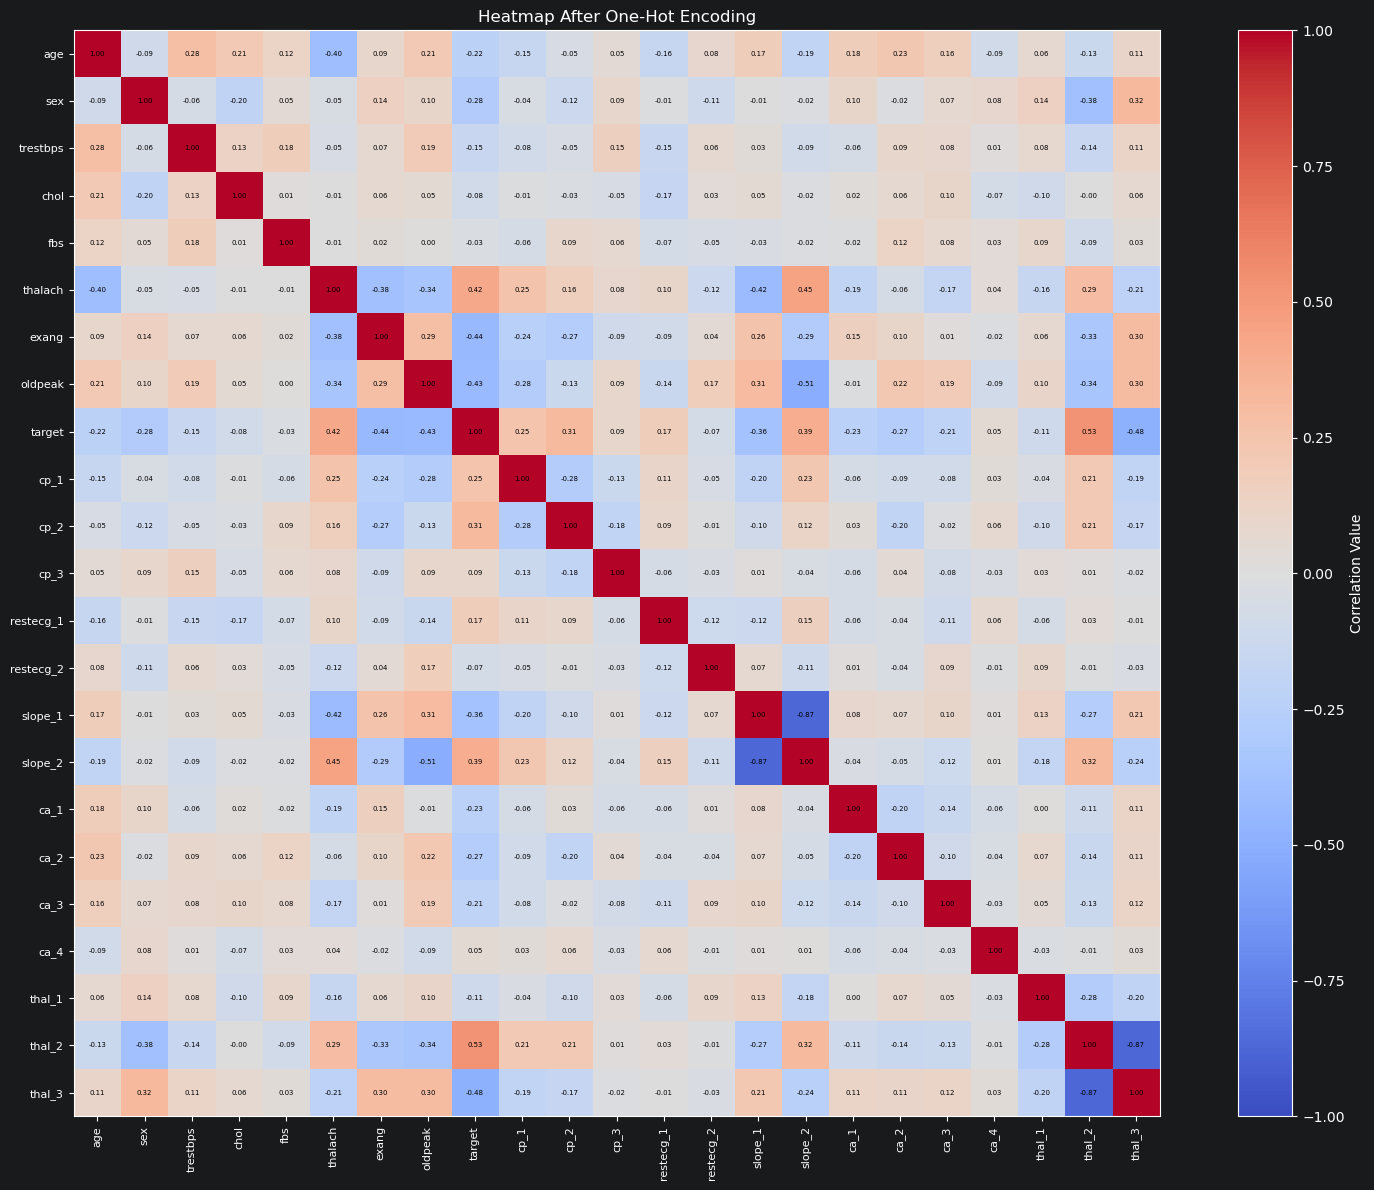

In [17]:
# Heatmap after one-hot encoding
encoded_correlation = heart_data_encoded.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
plt.imshow(encoded_correlation, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Value')
plt.title('Heatmap After One-Hot Encoding')
plt.xticks(range(len(encoded_correlation.columns)), encoded_correlation.columns, rotation=90, fontsize=8)
plt.yticks(range(len(encoded_correlation.columns)), encoded_correlation.columns, fontsize=8)

# Show values inside each box
for row in range(len(encoded_correlation.columns)):
    for col in range(len(encoded_correlation.columns)):
        value = encoded_correlation.iloc[row, col]
        plt.text(col, row, f'{value:.2f}', ha='center', va='center', fontsize=5, color='black')

plt.tight_layout()
plt.show()


Splitting the Features and Target

In [18]:
X = heart_data_encoded.drop(columns='target', axis=1)
Y = heart_data_encoded['target']


In [19]:
print(X)

     age  sex  trestbps  chol  fbs  thalach  exang  oldpeak  cp_1  cp_2  ...  \
0     63    1       145   233    1      150      0      2.3     0     0  ...   
1     37    1       130   250    0      187      0      3.5     0     1  ...   
2     41    0       130   204    0      172      0      1.4     1     0  ...   
3     56    1       120   236    0      178      0      0.8     1     0  ...   
4     57    0       120   354    0      163      1      0.6     0     0  ...   
..   ...  ...       ...   ...  ...      ...    ...      ...   ...   ...  ...   
298   57    0       140   241    0      123      1      0.2     0     0  ...   
299   45    1       110   264    0      132      0      1.2     0     0  ...   
300   68    1       144   193    1      141      0      3.4     0     0  ...   
301   57    1       130   131    0      115      1      1.2     0     0  ...   
302   57    0       130   236    0      174      0      0.0     1     0  ...   

     restecg_2  slope_1  slope_2  ca_1 

In [20]:
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 302, dtype: int64


Splitting the Data into Training data & Test Data

In [21]:

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)


In [22]:
print(X.shape, X_train.shape, X_test.shape)

(302, 22) (241, 22) (61, 22)


Model Training

Logistic Regression

In [23]:
model = LogisticRegression(max_iter=5000)

In [24]:
# training the LogisticRegression model with Training data
model.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


Model Evaluation

In [26]:
# accuracy on training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [27]:
print('Accuracy on Training data : ', training_data_accuracy)

Accuracy on Training data :  0.8713692946058091


In [28]:
# accuracy on test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [29]:
print('Accuracy on Test data : ', test_data_accuracy)

Accuracy on Test data :  0.8360655737704918


In [30]:
print(confusion_matrix(Y_test, X_test_prediction))
print(classification_report(Y_test, X_test_prediction))

[[22  6]
 [ 4 29]]
              precision    recall  f1-score   support

           0       0.85      0.79      0.81        28
           1       0.83      0.88      0.85        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



Final Model With Scaling

In [31]:
columns_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()
X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

print('Before scaling:')
print(X_train[columns_to_scale].head())

print('After scaling:')
print(X_train_scaled[columns_to_scale].head())


Before scaling:
     age  trestbps  chol  thalach  oldpeak
59    57       128   303      159      0.0
247   66       160   246      120      0.0
289   55       128   205      130      2.0
288   57       110   335      143      3.0
64    58       140   211      165      0.0
After scaling:
          age  trestbps      chol   thalach   oldpeak
59   0.289062 -0.192086  1.222784  0.405122 -0.889676
247  1.267182  1.590543  0.035438 -1.364273 -0.889676
289  0.071702 -0.192086 -0.818618 -0.910582  0.771788
288  0.289062 -1.194814  1.889363 -0.320784  1.602520
64   0.397742  0.476400 -0.693634  0.677336 -0.889676


 new Logistic Regression model using the scaled data and compare the accuracy.

In [32]:
scaled_model = LogisticRegression(max_iter=5000)
scaled_model.fit(X_train_scaled, Y_train)

scaled_train_prediction = scaled_model.predict(X_train_scaled)
scaled_test_prediction = scaled_model.predict(X_test_scaled)

scaled_training_accuracy = accuracy_score(Y_train, scaled_train_prediction)
scaled_test_accuracy = accuracy_score(Y_test, scaled_test_prediction)

print('Original Test Accuracy:', test_data_accuracy)
print('Final Scaled Model Test Accuracy:', scaled_test_accuracy)


Original Test Accuracy: 0.8360655737704918
Final Scaled Model Test Accuracy: 0.8360655737704918


This confusion matrix and report show the detailed scaled model performance.

In [33]:
print(confusion_matrix(Y_test, scaled_test_prediction))
print(classification_report(Y_test, scaled_test_prediction))


[[22  6]
 [ 4 29]]
              precision    recall  f1-score   support

           0       0.85      0.79      0.81        28
           1       0.83      0.88      0.85        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



This simple chart compares the original model and scaled model test accuracy.

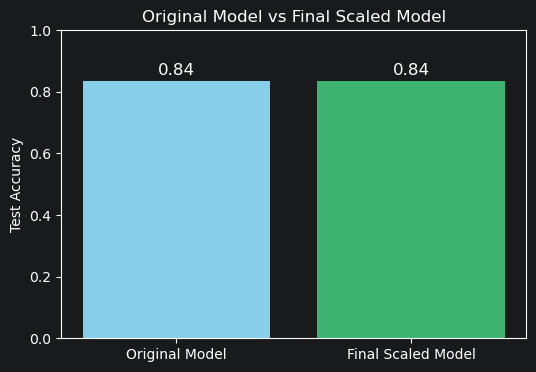

In [34]:
# Compare original model and final scaled model accuracy
model_names = ['Original Model', 'Final Scaled Model']
test_scores = [test_data_accuracy, scaled_test_accuracy]

plt.figure(figsize=(6, 4))
plt.bar(model_names, test_scores, color=['skyblue', 'mediumseagreen'])
plt.title('Original Model vs Final Scaled Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)

for index, value in enumerate(test_scores):
    plt.text(index, value + 0.02, f'{value:.2f}', ha='center', fontsize=12)

plt.show()


GridSearchCV for Better Logistic Regression

In [ ]:

X_for_grid = X.copy()

grid_scaler = StandardScaler()
X_for_grid[columns_to_scale] = grid_scaler.fit_transform(X_for_grid[columns_to_scale])

logistic_model = LogisticRegression(max_iter=5000)

parameters = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

grid_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=parameters,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_for_grid, Y)

print('Best parameters:')
print(grid_search.best_params_)

print('Best cross-validation accuracy:')
print(grid_search.best_score_)


Now we use the best settings from GridSearchCV and test the model on our train/test split.

In [37]:

best_logistic_model = LogisticRegression(
    C=grid_search.best_params_['C'],
    solver=grid_search.best_params_['solver'],
    penalty=grid_search.best_params_['penalty'],
    max_iter=5000
)

best_logistic_model.fit(X_train_scaled, Y_train)

best_model_prediction = best_logistic_model.predict(X_test_scaled)
best_model_accuracy = accuracy_score(Y_test, best_model_prediction)

print('Previous final scaled model accuracy:', scaled_test_accuracy)
print('GridSearchCV best model test accuracy:', best_model_accuracy)


Previous final scaled model accuracy: 0.8360655737704918
GridSearchCV best model test accuracy: 0.8524590163934426


Classification report for the GridSearchCV best model

In [38]:
print(confusion_matrix(Y_test, best_model_prediction))
print(classification_report(Y_test, best_model_prediction))


[[23  5]
 [ 4 29]]
              precision    recall  f1-score   support

           0       0.85      0.82      0.84        28
           1       0.85      0.88      0.87        33

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



This chart compares the previous final model with the GridSearchCV best model.

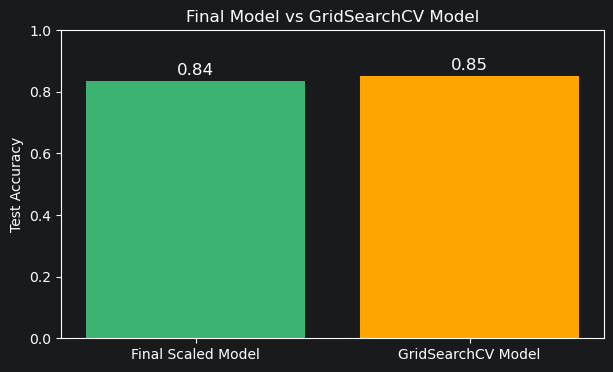

In [41]:
model_names = ['Final Scaled Model', 'GridSearchCV Model']
accuracies = [scaled_test_accuracy, best_model_accuracy]

plt.figure(figsize=(7, 4))
plt.bar(model_names, accuracies, color=['mediumseagreen', 'orange'])
plt.title('Final Model vs GridSearchCV Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)

for index, value in enumerate(accuracies):
    plt.text(index, value + 0.02, f'{value:.2f}', ha='center', fontsize=12)

plt.show()


 new KNN model using the scaled data and compare the accuracy.


In [44]:


knn_model = KNeighborsClassifier(n_neighbors=5)

# Train KNN model
knn_model.fit(X_train_scaled, Y_train)

# Predict test data
knn_prediction = knn_model.predict(X_test_scaled)

# Check accuracy
knn_accuracy = accuracy_score(Y_test, knn_prediction)

print('Logistic Regression GridSearchCV Accuracy:', best_model_accuracy)
print('KNN Accuracy:', knn_accuracy)

print()
print('KNN Confusion Matrix:')
print(confusion_matrix(Y_test, knn_prediction))

print()
print('KNN Classification Report:')
print(classification_report(Y_test, knn_prediction))


Logistic Regression GridSearchCV Accuracy: 0.8524590163934426
KNN Accuracy: 0.7540983606557377

KNN Confusion Matrix:
[[20  8]
 [ 7 26]]

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



Export Best Model as Pickle File

In [ ]:
# Export the best model and preprocessing information as a pickle file
import pickle
from pathlib import Path

export_folder = Path('')
export_folder.mkdir(exist_ok=True)

model_bundle = {
    'model': best_logistic_model,
    'scaler': scaler,
    'categorical_columns': categorical_columns,
    'columns_to_scale': columns_to_scale,
    'feature_columns': list(X.columns),
    'target_mapping': {
        0: 'No Heart Disease',
        1: 'Heart Disease Detected'
    },
    'best_params': grid_search.best_params_,
    'test_accuracy': best_model_accuracy,
    'confusion_matrix': confusion_matrix(Y_test, best_model_prediction).tolist(),
    'classification_report': classification_report(Y_test, best_model_prediction)
}

pickle_file_path = export_folder / 'heart_disease_best_model.pickle'

with open(pickle_file_path, 'wb') as file:
    pickle.dump(model_bundle, file)

print('Model exported successfully!')
print('File saved at:', pickle_file_path)
